## 1) Radioaktives Präparat, Teil 1

In einer Messreihe zur Bestimmung der Lebensdauer eines schwach radioaktiven Präparats wurden in gleichen Zeitintervallen die folgende Anzahl an Zerfällen registriert:

In [74]:
zerfaelle = [1, 1, 5, 4, 2, 0, 3, 2, 4, 1, 2, 1, 1, 0, 1, 1, 2, 1]

### a) Darstellung als Histogram
Stellen Sie die Daten mittels eines Histogramms [`plt.hist`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html) grafisch dar. Achten
Sie dabei auf die richtige Wahl der Bins und beschriften Sie die Achsen (`plt.xlabel`).

**Hinweise:** 

- Sie können in Jupyter direkt die Dokumentation einer Funktion mit `help` aufrufen: `help(plt.hist)`.

- Die meiste Kontrolle über das Binning haben Sie, wenn Sie die Bingrenzen explizit definiere - zum Beispiel mit `bins=np.arange(0,6.1,1)`.

In [75]:
import matplotlib.pyplot as plt
import numpy as np

help(plt.hist)

Help on function hist in module matplotlib.pyplot:

hist(x: 'ArrayLike | Sequence[ArrayLike]', bins: 'int | Sequence[float] | str | None' = None, range: 'tuple[float, float] | None' = None, density: 'bool' = False, weights: 'ArrayLike | None' = None, cumulative: 'bool | float' = False, bottom: 'ArrayLike | float | None' = None, histtype: "Literal['bar', 'barstacked', 'step', 'stepfilled']" = 'bar', align: "Literal['left', 'mid', 'right']" = 'mid', orientation: "Literal['vertical', 'horizontal']" = 'vertical', rwidth: 'float | None' = None, log: 'bool' = False, color: 'ColorType | Sequence[ColorType] | None' = None, label: 'str | Sequence[str] | None' = None, stacked: 'bool' = False, *, data=None, **kwargs) -> 'tuple[np.ndarray | list[np.ndarray], np.ndarray, BarContainer | Polygon | list[BarContainer | Polygon]]'
    Compute and plot a histogram.
    
    This method uses `numpy.histogram` to bin the data in *x* and count the
    number of values in each bin, then draws the distributio

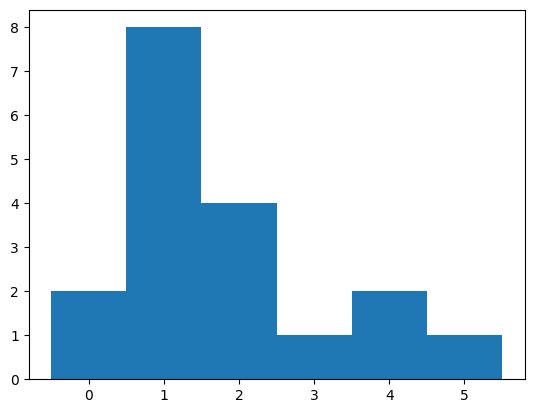

Text(0.5, 0, 'Zerfälle k')

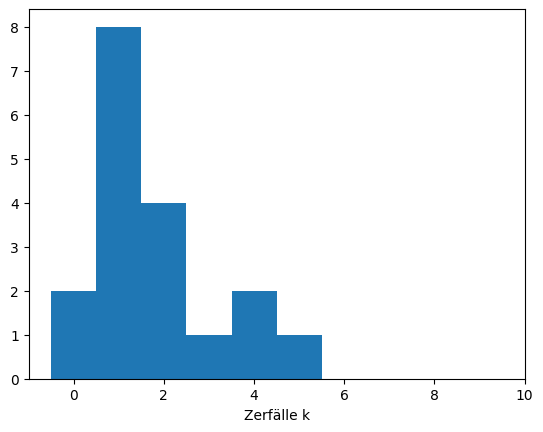

In [76]:
plt.hist(zerfaelle, bins=np.arange(-0.5,6.1,1))
plt.show()
plt.hist(zerfaelle,bins=10,range=(-0.5,9.5))
plt.xlabel("Zerfälle k")

### b) Mittelwert und Standardabweichung

Berechnen Sie den Mittelwert der Zerfälle pro Zeitintervall und die Standardabweichung. Geben Sie zudem die erwartete Unsicherheit auf den Mittelwert an.

**Hinweise**: 
- Führen Sie die Berechnung von Mittelwert und Standardabweichung zuerst *per Hand* und anschließend mit Hilfe von `numpy`-Funktionen durch. Mittelwert und Standardabweichung eines Arrays `s` erhalten Sie durch `np.mean(s)` und `np.std(s)`.
- Benutzen Sie für die formatierte Ausgabe, z.B. `print(f"Mittelwert={np.mean(zerfaelle):.3f}")`




In [77]:
print(f"Mittelwert={np.mean(zerfaelle):.3f}")
mean=np.mean(zerfaelle)
print(f"Mittelwert={mean:.3f}")
print(f"Standartabweichung={np.std(zerfaelle):.3f}")

Fehler= np.std(zerfaelle)/np.sqrt(len(zerfaelle))

print(f"Mittelwert = {np.mean(zerfaelle):.3f} ± {Fehler:.3f}")

Mittelwert=1.778
Mittelwert=1.778
Standartabweichung=1.356
Mittelwert = 1.778 ± 0.320


**Folien**

### c) Wahrscheinlichkeitsverteilung

Welche Wahrscheinlichkeitsverteilung erwarten Sie für die Daten? 

Was sind die besten Schätzungen für die Parameter dieser Verteilung?

Prüfen Sie, ob die Verteilung der Zufallsvariablen mit der erwarteten Form übereinstimmt. 
Verwenden Sie die Wahrscheinlichkeitsverteilungen aus [`scipy.stats`](https://docs.scipy.org/doc/scipy/reference/stats.html) und plotten Sie die Daten zusammen mit der passenden “Hypothese”. 

Verwenden Sie `plt.plot`zum Plotten und `plt.legend` zum Beschriften. Beachten Sie, dass das Integral der Funktion der Zahl der Messpunkte entsprechen muss und skalieren Sie entsprechend die Wahrscheinlichkeitsverteilung. 

Die Werte für die $x$-Achse können Sie für diskrete Variablen mit `np.arange` erzeugen,  für kontinuierliche Variablen nutzen Sie `np.linspace`. 

Die `scipy.stats`-Funktionen akzeptieren (Numpy-)Arrays als Argumente, sodass Sie alle Funktionswerte in einem Aufruf ausrechnen lassen können.

In [78]:
import scipy.stats as stats

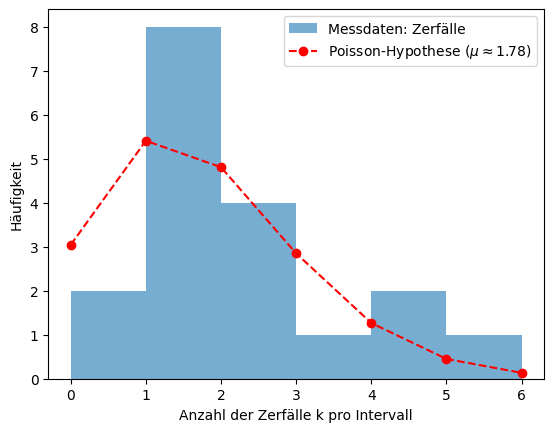

In [79]:
n_messungen=len(zerfaelle)

# Erwartung: Poisson Verteilung
mu_schaetzwert= np.mean(zerfaelle)

plt.hist(zerfaelle, bins=np.arange(0, 7, 1), label='Messdaten: Zerfälle', alpha=0.6, density=False)

# Skalierung: Wahrscheinlichkeit * Gesamtzahl der Messungen
x = np.arange(0, 7)
y_poisson = stats.poisson.pmf(x, mu_schaetzwert) * n_messungen

plt.plot(x, y_poisson, 'ro--', label=f'Poisson-Hypothese ($ \\mu \\approx {mu_schaetzwert:.2f}$)')
plt.xlabel('Anzahl der Zerfälle k pro Intervall')
plt.ylabel('Häufigkeit')
plt.legend()
plt.show()


## 2) Poisson-Verteilung 

### a) Generieren Sie Stichproben mit jeweils $10\,000$ Poisson-verteilte Zufallsvariablen für die unten  angegebenen µ-Werte.

Die $\mu$-Werte sind:
```
mus = [1, 3, 5, 10, 12, 15, 20, 25, 30, 35, 40, 45, 50]

```


Benutzen Sie `scipy.stats.poisson.rvs`.

Sie können zum Beispiel die Zufallszahlen in ein Numpy-Array über eine Schleife füllen:
```
mus = [1, 3, 5, 10, 12, 15, 20, 25, 30, 35, 40, 45, 50]
#help(stats.poisson.rvs
ks = np.zeros((len(mus),10000))
for i, mu in enumerate(mus):
     ks[0] = 
```



In [80]:
mus= [1, 3, 5, 10, 12, 15, 20, 25, 30, 35, 40, 45, 50]
n_samples=10000

ks = np.zeros((len(mus), n_samples))
for i, mu in enumerate(mus):
    # Generiere 10.000 Zufallswerte für das aktuelle mu
    ks[i] = stats.poisson.rvs(mu, size=n_samples) 

ks

array([[ 0.,  2.,  0., ...,  0.,  2.,  0.],
       [ 2.,  5.,  3., ...,  2.,  2.,  2.],
       [ 8.,  2.,  6., ...,  6.,  4.,  5.],
       ...,
       [32., 40., 38., ..., 40., 54., 34.],
       [36., 41., 37., ..., 46., 35., 44.],
       [46., 49., 54., ..., 59., 48., 44.]])

### b) Stellen Sie die Werte als Histogramme in einer Abbildung da.

**Hinweise**:
- Verwenden Sie das Argument `label=` von `plt.hist` und `plt.legend` für eine Legende.

- Probieren Sie `histype='step'`oder `alpha=0.6` für eine bessere Darstellung.

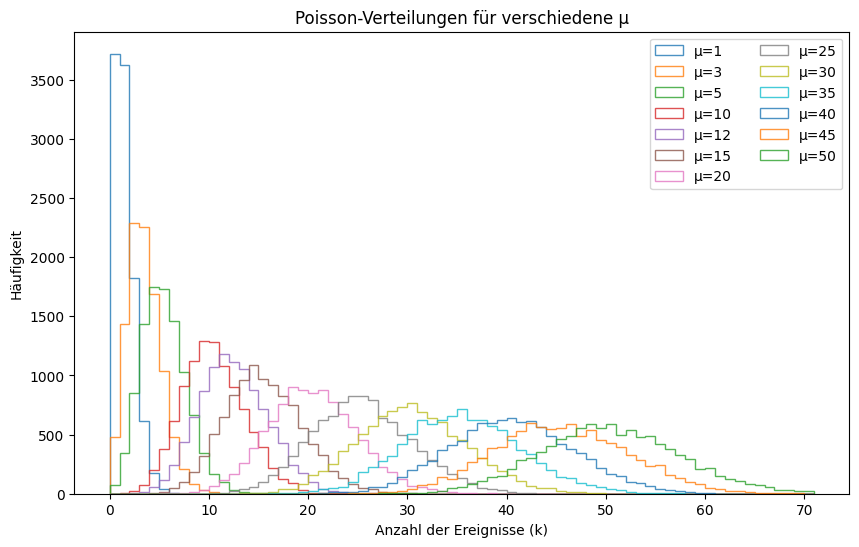

In [81]:
plt.figure(figsize=(10, 6))
for i, mu in enumerate(mus):
    plt.hist(ks[i], bins=np.arange(0, 72, 1), label=f'μ={mu}', histtype='step', alpha=0.8)

plt.xlabel('Anzahl der Ereignisse (k)')
plt.ylabel('Häufigkeit')
plt.title('Poisson-Verteilungen für verschiedene μ')
plt.legend(loc='upper right', ncol=2)
plt.show()

### c) Stellen Sie grafisch den Mittelwert, die Varianz und die Schiefe (Skewness) der Stichproben gegen $\mu$ dar.

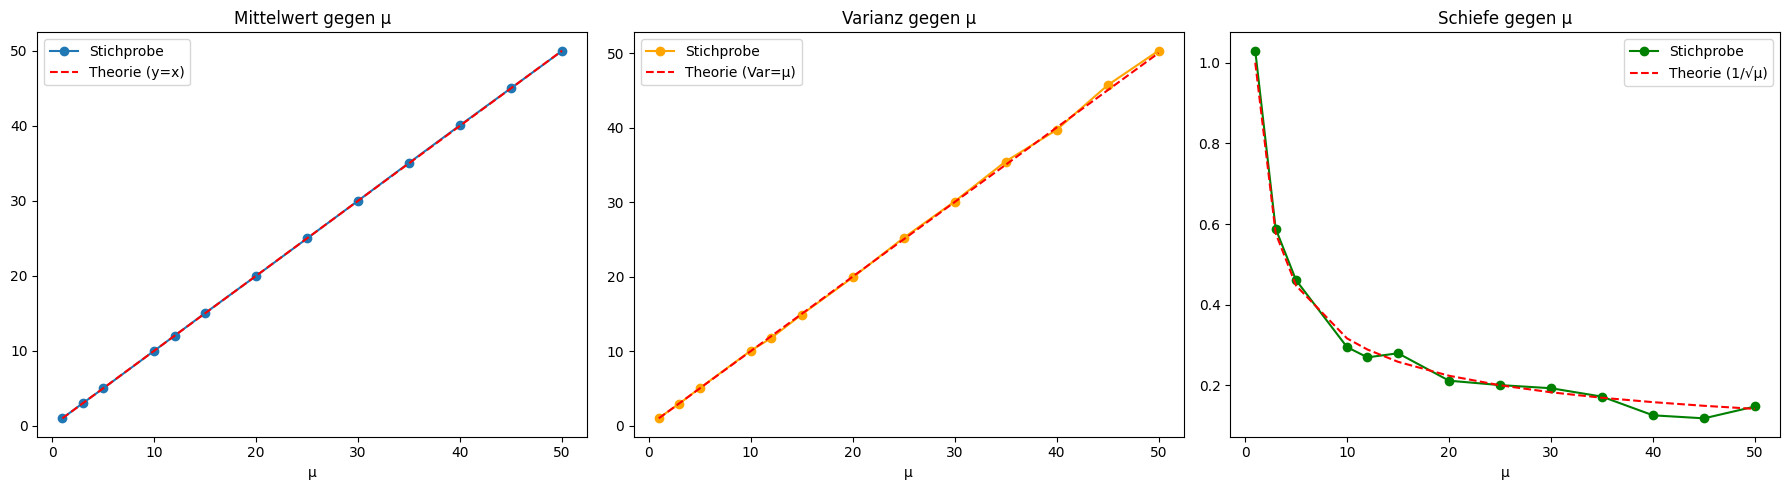

In [82]:
mittelwerte = np.mean(ks, axis=1)
varianzen = np.var(ks, axis=1)
schiefe = stats.skew(ks, axis=1)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
# ax[0] ist der erste, ax[1] der zweite, ax[2] der dritte Plot.

# Plot 1: Mittelwert
ax[0].plot(mus, mittelwerte, 'o-', label='Stichprobe')
ax[0].plot(mus, mus, 'r--', label='Theorie (y=x)')
ax[0].set_title('Mittelwert gegen μ')
ax[0].set_xlabel('μ')
ax[0].legend()

# Plot 2: Varianz
ax[1].plot(mus, varianzen, 'o-', color='orange', label='Stichprobe')
ax[1].plot(mus, mus, 'r--', label='Theorie (Var=μ)')
ax[1].set_title('Varianz gegen μ')
ax[1].set_xlabel('μ')
ax[1].legend()

# Plot 3: Schiefe
ax[2].plot(mus, schiefe, 'o-', color='green', label='Stichprobe')
ax[2].plot(mus, 1/np.sqrt(mus), 'r--', label='Theorie (1/√μ)')
ax[2].set_title('Schiefe gegen μ')
ax[2].set_xlabel('μ')
ax[2].legend()

plt.tight_layout()
plt.show()

**Folien**

## 3. Standardnormalverteilung

### a)  Erzeugen Sie Zufallszahlen, die einer Standardnormalverteilungen ($\mu= 0, \sigma = 1$) folgen. 

Generieren Sie Stichproben mit $10^3$, $10^4$ und $10^5$ Einträgen und stellen Sie sie in einem Histogramm dar.

**Hinweis**: Nutzen Sie für die Erzeugung die Funktion `scipy.stats.norm.rvs`

### b)  Mittelwert und Standardabweichnung

Überprüfen Sie, dass Mittelwert und Standardabweichung der Verteilung den gesetzten Werten entspricht (innerhalb einer gewissen Toleranz).

## Exkurs: Stichprobenvarianz/Besselkorrektur

Die Varianz von $N$ Zufallsvariablen ist definiert als $V = \frac{1}{N} \sum_{i=1}^N (x_i - \bar x)^2$ mit dem Mittelwert  $<x> = \frac{1}{N} \sum_{i=1}^N x_i$. Diese kann man auch die empirische Varianz nennen.

Oft ist aber die Absicht nicht einfach diese (empirische) Varianz der Daten zu bestimmen, sondern die Varianz der den Daten zugrundeliegenden Wahrscheinlichkeitsfunktion abzuschätzen. Man kann dies auch als Varianz, die man mit unendlich vielen Messungen bekommen würde, ansehen. 

Testen wir nun für Stichproben der Größe $N=3,5,8,10,15,20,30,40,50,100$, ob die empirische Varianz auch ein guter Schätzer für diese "wahre" Varianz ist. Dafür generieren wir 10.000 Mal jeweils $N$ normalverteilte Zufallszahlen und berechnen dafür die empirische Varianz. Ein Schätzer ist erwartungstreu, wenn der Mittelwert der Schätzungen im Limes unendlich vieler Wiederholungen dem wahren Wert enspricht. Tragen Sie dafür das Verhältnis zwischen dem Mittelwert der geschätzen Varianzen $\langle\hat V\rangle$ und der wahren Varianz gegen $N$ auf.
Machen Sie noch einen zweiten Plot, bei dem Sie die Differenz $\langle\hat V\rangle - V_\text{wahr}$ auftragen und noch mit $N$ skalieren. Um welchen Wert liegt diese skalierte Differenz im Mittel daneben?


In [83]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

Ns = [3,5,8,10,15,20,30,40,50,100]
n_sim = 10000
wahre_var = 1.0 # Da Standardnormalverteilung (sigma=1) genutzt wird


Wir haben nun empirisch den nötigen Korrekturfaktor $\frac{N}{N-1}$ gefunden. Dieser wird Besselkorrektur genannt. Der erwartungstreue Schätzer der Varianz (Stichprobenvarianz) ist $\hat V = \frac{1}{N-1} \sum_{i=1}^N (x_i - \bar x)^2$.

In `Numpy` benutzt man diesen, indem man `ddof=1` als Zusatzargument beim Aufruf von `np.var` und `np.std` hinzufügt. Wiederholen Sie einmal den Test mit dieser Option.

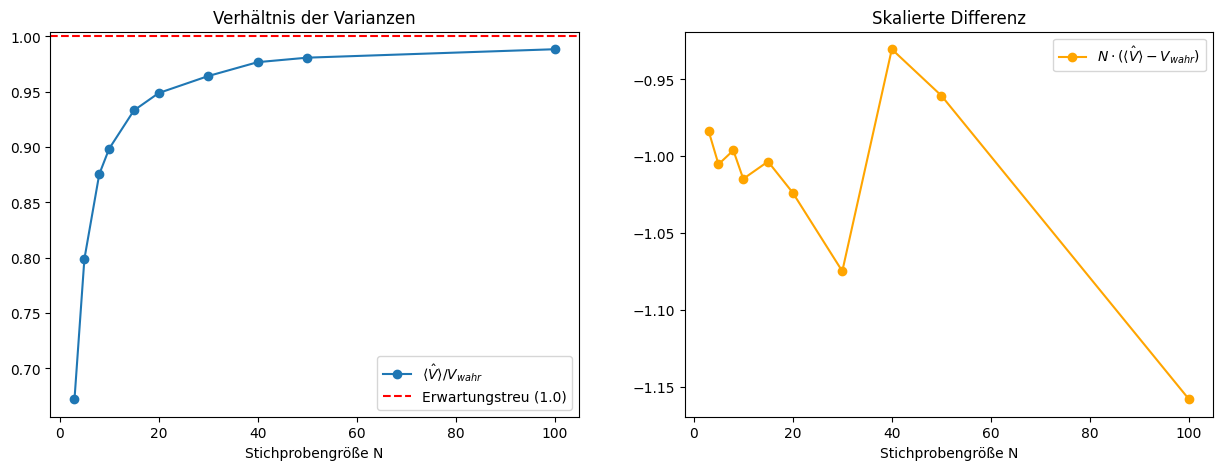

In [84]:
verhaeltnisse = []
differenzen_skaliert = []

for N in Ns:
    # Generiere 10.000 Mal N normalverteilte Zufallszahlen
    proben = stats.norm.rvs(loc=0, scale=1, size=(n_sim, N))
    
    # Berechne die empirische Varianz (ohne Korrektur, ddof=0)
    empirische_varianzen = np.var(proben, axis=1, ddof=0)
    
    # Mittelwert der Schätzungen <V_hat>
    mittel_v_hat = np.mean(empirische_varianzen)
    
    # Verhältnis und skalierte Differenz berechnen
    verhaeltnisse.append(mittel_v_hat / wahre_var)
    differenzen_skaliert.append((mittel_v_hat - wahre_var) * N)

# Grafische Darstellung
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Verhältnis gegen N
ax[0].plot(Ns, verhaeltnisse, 'o-', label=r'$\langle\hat V\rangle / V_{wahr}$')
ax[0].axhline(1.0, color='red', linestyle='--', label='Erwartungstreu (1.0)')
ax[0].set_title('Verhältnis der Varianzen')
ax[0].set_xlabel('Stichprobengröße N')
ax[0].legend()

# Plot 2: Skalierte Differenz gegen N
ax[1].plot(Ns, differenzen_skaliert, 'o-', color='orange', label=r'$N \cdot (\langle\hat V\rangle - V_{wahr})$')
ax[1].set_title('Skalierte Differenz')
ax[1].set_xlabel('Stichprobengröße N')
ax[1].legend()

plt.show()

### c) Wahrscheinlichkeitsdichtefunktion

Zurück zu den drei Stichproben mit normalverteilten Zufallszahlen aus 3a) und b). 

Verwenden Sie nun außerdem eine analytische Gauß-Funktion (`scipy.stats.norm.pdf`) und zeichnen Sie diese zusammen mit dem Histogramm. Achten Sie auf identisches Binning und Normierung!


**Hinweis**: Es kann praktisch sein, Plots nebeneinander darzustellen. Benutzen Sie dafür `plt.subplots`, 
z.B. für drei Plots nebeneinander:

`fix,axes = plt.subplots(1,3,figsize=(20,5))`

Dann können einzelne Plots über ihre Achsen angesprochen werden, z. B. `axes[0].hist(...)`.

### d) Kumulierte Verteilung

Zeichnen Sie nun die Histogramme mit der Option `cumulative=True` und zeichnen Sie zum Vergleich die kumulierte Wahrscheinlichkeitsdichtefunktion `scipy.stats.norm.cdf` dazu.

**Hinweis**: Um die Normierung zu vereinfachen, können Sie diesmal `density=True` im Histogram verwenden.

NameError: name 'scipy' is not defined

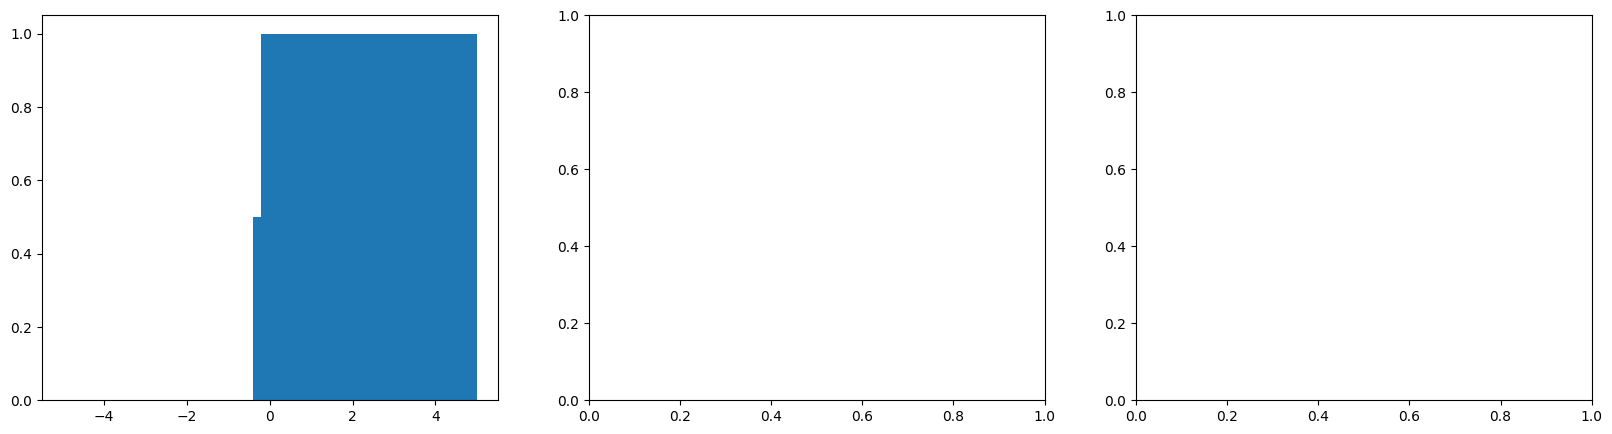

In [85]:
fig, axes = plt.subplots(1,3,figsize=(20,5))
for i in range(3):
    axes[i].hist(xs[i],range=(-5,5),bins=50,cumulative=True,density=True)
    axes[i].plot(x_vals, scipy.stats.norm.cdf(x_vals))

### d) Integrale

Berechnen Sie den Wahrscheinlichkeitsinhalt der $1\sigma$-, $2\sigma$- und $3\sigma$-Umgebungen aus den Stichproben und über die kumulierte Wahrscheinlichkeitsdichtefunktion.



In [ ]:
for n in [1,2,3]:
    print(f"im {n}-sigma Intervall:{stats.norm.cdf(n)-stats.norm.cdf(-n):.3f}")
print(np.sum(xs[2]<-1)+np.sum(xs[2]>1))

im 1-sigma Intervall:0.683
im 2-sigma Intervall:0.954
im 3-sigma Intervall:0.997


NameError: name 'xs' is not defined

### e) Poisson- und Normalverteilung
Zeichnen Sie die Poissonverteilung für $\mu=6,12,20,50,100$ und vergleichen Sie sie mit der Normalverteilung mit entsprechendem $\mu$ und $\sigma$.

Tragen Sie in einen zweiten Grafik die Differenz von Poisson- und Normalverteilung auf.

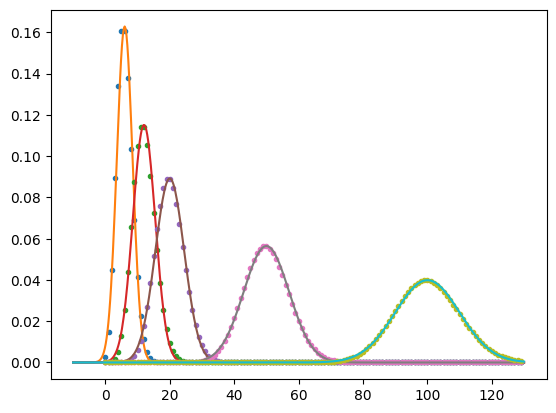

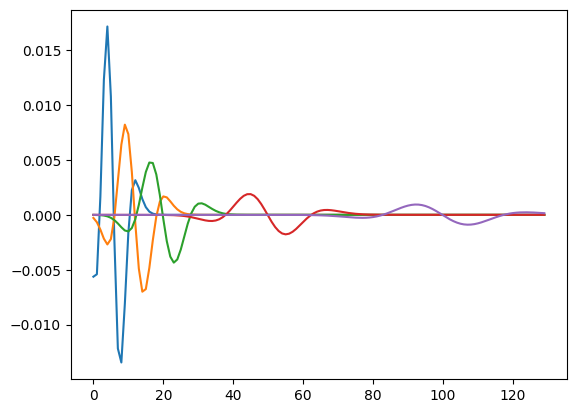

In [ ]:
mus=[6,12,20,50,100]
k_vals=np.arange(0,130,1)
x_vals=np.linspace(-10,130,500)
for mu in mus:
    plt.plot(k_vals, stats.poisson.pmf(k_vals,mu),'.')
    plt.plot(x_vals,stats.norm.pdf(x_vals,mu, np.sqrt(mu)),'-')
plt.show()

for mu in mus:
    plt.plot(k_vals, stats.poisson.pmf(k_vals,mu)-stats.norm.pdf(k_vals,mu, np.sqrt(mu)))
plt.show()

## f) Fehler auf Poisson-Messung?

Bei einem Zählexperiment - wie zum Beispiel auch der Zahl der Einträge in ein Histogrammbin - wird oft die Wurzel der Zahl der gezählten Ereignisse als Fehler  angenommen. Dabei wird angenommen, dass die Zahlen an Ereignissen bei wiederholten Messungen Poisson verteilt sind und die gemessene Zahl an Ereignissen $n$ der Erwartungswert $\mu$ dieser zugrundeliegenden Poissonverteilung ist. Die Standardabweichung der Poissonverteilung wäre dann in der Tat $\sqrt{n}$. 
Der wahre Wert von $\mu$ ist dabei aber nicht bekannt und wird nur über die Messung $n$ als $\mu=n$ abgeschätzt. Dieses Vorgehen ist bei kleinen $n$ nicht richtig. Berechnen Sie die Wahrscheinlichkeit, dass für verschiedene gemessene $n$-Werte $\mu$ im Intervall $n-\sqrt(n)$ und  $n+\sqrt(n)$ liegt:

$$P(n-\sqrt(n) \le \mu \le n+\sqrt(n)) = \int_{n-\sqrt(n)}^{n-\sqrt(n)} \text{Poisson}(n,\mu) d\mu$$


Tragen Sie die Wahrscheinlichkeiten für $n=0,...,20$ auf. Zeichnen Sie auch eine Linie mit dem erwarteten Konfidenzwert 0,683 mit [`matplotlib.pyplot.hlines`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hlines.html) ein. Für das Integral können Sie [`scipy.integrate.quad`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html) wie folgt benutzen: 

In [ ]:
from scipy.integrate import quad


## Exkurs: Numpy-Vectorize

Die direkte Berechnung über die parallele Verarbeitung in `numpy` mit
```
confidences = confidence(mus, mus-np.sqrt(mus), mus+np.sqrt(mus))
```
erzeugt leider einen Fehler, da unsere Funktion keine Arrays verarbeiten kann. 
Mit `numpy.vectorize` erzeugt man eine neue Funktion, die Numpy-Arrays auflösen kann, und die Originalfunktion ummantelt. Dies kann häufig nützlich sein, um eigene `for`-Schleifen zu vermeiden.

In [ ]:
confidences = confidence(mus, mus-np.sqrt(mus), mus+np.sqrt(mus))
#confidences = np.vectorize(confidence)(mus, mus-np.sqrt(mus), mus+np.sqrt(mus))
print(confidences)

**Folien**

## 4 Zentraler Grenzwertsatz (CLT)

Schreiben Sie ein Programm, das experimentell die Aussage des CLT nachweist, dass die Summe mehrerer beliebig verteilter Zufallsvariablen selbst Gauß-verteilt ist.

1) Ihr Programm soll zunächst eine Gleichverteilung mit Mittelwert 0 und Varianz 1 erzeugen. Überprüfen Sie Mittelwert und Varianz und stellen Sie die Häufigkeitsverteilung grafisch als Histogramm dar. Benutzen Sie  [`scipy.stats.uniform`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.uniform.html#scipy.stats.uniform).

(0.011596219959056879, 0.996036786644625)

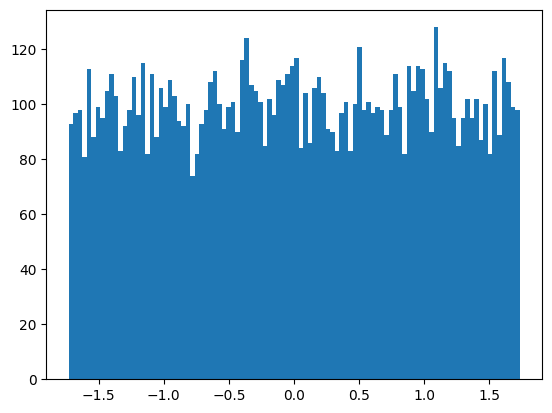

In [ ]:
xs=stats.uniform.rvs(-0.5*np.sqrt(12),np.sqrt(12),size=(10000))
plt.hist(xs,bins=100)
np.mean(xs),np.std(xs)

2) Berechnen Sie nun 1000 Zahlen, die jeweils die Summe von 2,3,5 und 10 derart gleichverteilter Zufallszahlen sind. Berechnen Sie jeweils Mittelwert und Varianz dieser Häufigkeitsverteilungen und füllen Sie sie in  Histogramme. Hinweis: Dies können Sie mit Hilfe einer Funktion umsetzen, die als Argument die gewünschte Wahrscheinlichkeitsverteilung sowie ihre Argumente erhält.

(array([ 17.,  39.,  50.,  83.,  76., 102., 128., 119., 138., 160., 165.,
        180., 188., 206., 228., 260., 269., 248., 304., 336., 342., 349.,
        360., 364., 396., 397., 339., 334., 336., 374., 305., 284., 257.,
        228., 235., 268., 199., 178., 200., 144., 150., 145., 120., 113.,
        101.,  63.,  46.,  38.,  28.,  11.]),
 array([-3.33605446, -3.20032198, -3.0645895 , -2.92885702, -2.79312454,
        -2.65739206, -2.52165958, -2.3859271 , -2.25019462, -2.11446214,
        -1.97872966, -1.84299718, -1.7072647 , -1.57153221, -1.43579973,
        -1.30006725, -1.16433477, -1.02860229, -0.89286981, -0.75713733,
        -0.62140485, -0.48567237, -0.34993989, -0.21420741, -0.07847493,
         0.05725755,  0.19299003,  0.32872251,  0.46445499,  0.60018747,
         0.73591995,  0.87165243,  1.00738491,  1.14311739,  1.27884987,
         1.41458235,  1.55031483,  1.68604731,  1.82177979,  1.95751227,
         2.09324475,  2.22897723,  2.36470971,  2.50044219,  2.63617468,
 

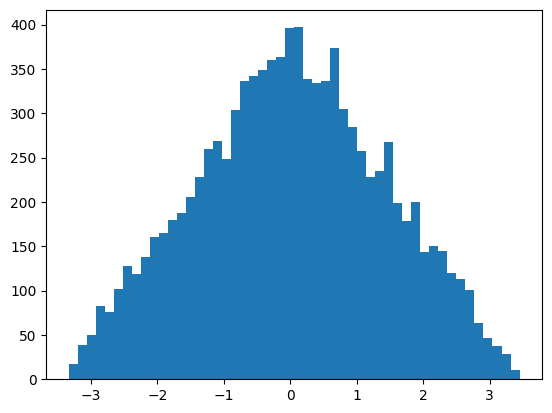

In [ ]:
xs=stats.uniform.rvs(-0.5*np.sqrt(12),np.sqrt(12),size=(10000,2))
xsums=np.sum(xs,axis=1)
plt.hist(xsums,bins=50)

4) Wiederholen Sie die vorige Aufgabe mit einer Binomial-, Poisson- und  $\chi^2$-Verteilung für die Summe von zehn Zufallszahlen.
Hinweis: All diese Verteilungen gibt es im Paket `scipy.stats`.

In [ ]:

xs=stats.poisson.rvs(-0.5*np.sqrt(12),np.sqrt(12),size=(10000,2))
xsums=np.sum(xs,axis=1)
plt.hist(xsums,bins=50)
pls.show()

stats.binom

stats.chi2

ValueError: Domain error in arguments. The `scale` parameter must be positive for all distributions, and many distributions have restrictions on shape parameters. Please see the `scipy.stats.poisson` documentation for details.

**Folien**

## 5 Simulation experimenteller Messungen und Fehler


Generieren Sie nun Messungen der Stromstärke $I_i$ bei zehn verschiedenen Spannungswerten $U_i$.
Die Spannung ändere sich dabei in 1 V-Schritten zwischen 6 V und 15 V.

Jede Stromstärkemessung $I_i$ normalverteilt mit Erwartungswert $\mu_i =  1{,}2(U_i-5 V)$ und $\sigma = 0.5$ A.

Tragen Sie $I_i$ gegen $U_i$ auf. Benutzen Sie `plt.errorbar`, um die Fehler mit einzuzeichnen.

Zeichnen Sie auch das theoretische Modell ein: $I = 1{,}2 (U - 5)$

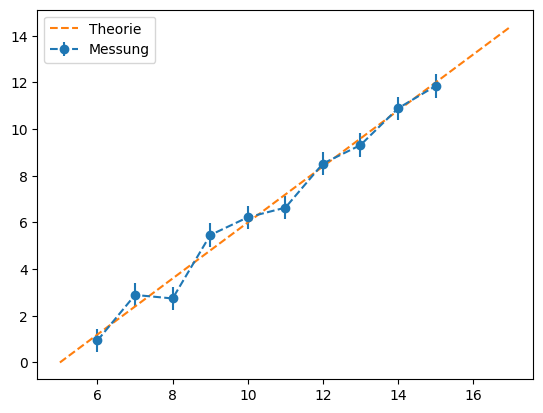

In [ ]:
Us =np.arange(6,15.1,1)
mus= 1.2*(Us-5)
Ierr=0.5
Imeass = stats.norm.rvs(mus, Ierr)

plt.errorbar(Us, Imeass, yerr=Ierr, fmt='--o', label="Messung")
U_vals=np.linspace(5,17,100)
plt.plot(U_vals,1.2*(U_vals-5), ls='--', label="Theorie")
plt.legend()
plt.show()

### Residuen
Berechnen Sie die Residuen, d.h. die Abweichungen der Messwerte vom Modell. Tragen Sie die Residuen $I_i - 1{,}2(𝑉_i−5)$ gegen $U_i$ auf. Zeichnen Sie auch die Fehler ein. Geben Sie den Mittelwert und die Standardabweichung der Residuen aus.

### Pull
Histogrammieren Sie die Pull-Werte: $\frac{I_i - I_\text{wahr}}{\sigma_i}$.
Berechnen Sie wiederum Mittelwert und Standardabweichung.

**In den nächsten Tagen: Wiederholung für 10 000 Messungen.**